In [1]:
import sqlite3
import requests
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool
from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine, text

In [2]:
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text
    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False}
    )


In [3]:
engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)

In [4]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model = "qwen3:32b", temperature=0, verbose=True)

In [5]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [6]:
tools = toolkit.get_tools()

In [7]:
import textwrap
from langchain_community.utilities.sql_database import SQLDatabase

def prettyprint(text):
    wrapper = textwrap.TextWrapper(width=80)
    wrapped_text = wrapper.wrap(str(text))
    print("\n".join(wrapped_text))
    print("\n\n")

In [8]:
from typing import Annotated
from langchain_core.tools import tool

In [9]:
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools)

In [10]:
from typing import List, Dict, Any
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

class QueryResponse(BaseModel):
    """Respond to the user with this"""

    answer: str = Field(
        description="The answer to the question"
    )

class AgentState(MessagesState):
    # Final structured response from the agent
    final_response: QueryResponse


In [11]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# define template for SQL querying
prompt_template = ChatPromptTemplate.from_template(
            "You are an agent designed to interact with a SQL database. "
            "Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer. "
            "You can order the results by a relevant column to return the most interesting examples in the database. "
            "Never query for all the columns from a specific table, only ask for the relevant columns given the question. "
            "You have access to tools for interacting with the database. "
            "Only use the below tools. Only use the information returned by the below tools to construct your final answer. "
            "You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again. "
            "DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database. "
            "Do not LIMIT your queries if you are doing aggregation. "
            "LIMIT the query if it is going to return more than 10000 rows. "
            "To start you should ALWAYS look at the tables in the database to see what you can query. "
            "Do NOT skip this step. Then you should query the schema of the most relevant tables."
            "Try to use exact names in the filters. Avoid using LIKE."
        )

generator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            prompt_template.format(dialect='SQLite')
        ),
        ("user", "{question}"),
        MessagesPlaceholder(variable_name="messages", optional=True)
    ]
)

generator_model = llm.bind_tools(tools)

# create chain from previous prompts
model_with_tools = generator_prompt | generator_model

In [12]:
template = ChatPromptTemplate.from_template(
            "Respond to the user's question using the data collected by the previous model."
            "Return the relevant data with the response."
        )

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            prompt_template.format(dialect='SQLite')
        ),
        ("user", "{question}"),
        ("system", "{messages}")
        #MessagesPlaceholder(variable_name="messages", optional=True)
    ]
)



# create chain from previous prompts
model_with_tools = generator_prompt | generator_model
model_with_structured_output = prompt | llm.with_structured_output(QueryResponse)

In [13]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# define template for SQL querying
prompt_template = ChatPromptTemplate.from_template(
            "You are an agent designed to interact with a SQL database. "
            "Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer. "
            "You can order the results by a relevant column to return the most interesting examples in the database. "
            "Never query for all the columns from a specific table, only ask for the relevant columns given the question. "
            "You have access to tools for interacting with the database. "
            "Only use the below tools. Only use the information returned by the below tools to construct your final answer. "
            "You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again. "
            "DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database. "
            "Do not LIMIT your queries if you are doing aggregation. "
            "LIMIT the query if it is going to return more than 10000 rows. "
            "To start you should ALWAYS look at the tables in the database to see what you can query. "
            "Do NOT skip this step. Then you should query the schema of the most relevant tables."
            "Try to use exact names in the filters. Avoid using LIKE."
        )

generator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            prompt_template.format(dialect='SQLite')
        ),
        ("user", "{question}"),
        MessagesPlaceholder(variable_name="messages", optional=True)
    ]
)

generator_model = llm.bind_tools(tools)

# create chain from previous prompts
model_with_tools = generator_prompt | generator_model

In [14]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langchain_core.messages import trim_messages
from langchain_core.messages.utils import count_tokens_approximately


# Define the function that calls the model
def call_model(state: AgentState):
    question = state["messages"][0]
    # print('### Question ###')
    # print(question)
    response = model_with_tools.invoke(state["messages"])
    #response = model_with_tools.invoke({"messages": state["messages"], "question": question})
    # We return a list, because this will get added to the existing list
    prettyprint(f'response: {response}')
    return {"messages": [response]}


# Define the function that responds to the user
def respond(state: AgentState):
    question = state['messages'][0].content
    response = model_with_structured_output.invoke({"messages": state["messages"][-2].content, "question": question})
    print('### Respond Node ###')
    prettyprint(f'final_response: {response}')

    return {"final_response": response}


# Define the function that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    # If there is no function call, then we respond to the user
    if not last_message.tool_calls or len(messages) > 60:
        return "respond"
    # Otherwise if there is, we continue
    else:
        # print('### Continue ###')
        return "continue"


# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("respond", respond)
workflow.add_node("tools", ToolNode(tools))

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.set_entry_point("agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond",
    },
)

workflow.add_edge("tools", "agent")
workflow.add_edge("respond", END)
graph = workflow.compile()

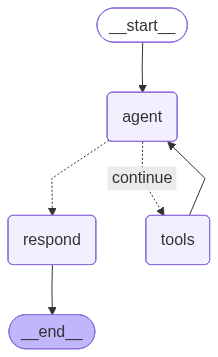

In [15]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [16]:
import uuid
def start_conversation():
    thread_id = uuid.uuid4()
    print(f'Thread ID: {thread_id}')
    return {"configurable": {"thread_id": thread_id}, 'recursion_limit': 150}


def answer_question(query, config):
    print('### Question ###')
    print(query)
    config = start_conversation()
    answer = graph.invoke(input={"messages": [("human", query)]}, config=config)[
        "final_response"
    ]
    print('### Answer ###')
    prettyprint(answer.answer)
    return answer

In [17]:
question = "Total number of artist in the db?"
config = start_conversation()
answer = answer_question(question, config)

Thread ID: 9f4af321-dd07-40f3-aa4c-482b5ac23b91
### Question ###
Total number of artist in the db?
Thread ID: c3035702-8bc8-4022-95f9-23f139751f87
response: content="<think>\nOkay, let's see. The user is asking for the total
number of artists in the database. First, I need to figure out which table
contains artist information. Since I'm not sure, I should start by listing all
the tables in the database using the sql_db_list_tables function. That will give
me an idea of what tables are available.\n\nOnce I have the list of tables, I
can check the schema of the relevant table, probably something like 'artists' or
'artist' using the sql_db_schema function. After identifying the correct table,
I can then write a SQL query to count the number of entries in that table. The
query would be something like SELECT COUNT(*) FROM artists. But before
executing, I should use the sql_db_query_checker to make sure the query is
correct. If there's an error, I'll need to adjust the query based on the
fee

## Plan-execute Section

In [18]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

In [19]:
from pydantic import BaseModel, Field


class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

In [20]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",
        "For the given objective, come up with a simple step by step plan."
        "This plan should involve individual tasks, that if executed correctly will yield the correct answer. "
        "Do not add any superfluous steps. "
        "Make sure that each step has all the information needed - do not skip steps."
        "Plan the steps needed to answer the question regardless of the tools available."
        "The executor agent will have access to a database containing all the financial data needed for this task.",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | llm.with_structured_output(Plan)

In [21]:
from typing import Union
from pydantic import BaseModel, Field


class Response(BaseModel):
    """Response to user."""

    response: str

class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )
    # is_responded: bool

class ResponseAct(BaseModel):
    response: str
    action:str = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )
    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )
    responded: bool

replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan.
    This plan should involve individual tasks, that if executed correctly will yield the correct answer.
    Do not add any superfluous steps. The result of the final step should be the final answer.
    Make sure that each step has all the information needed - do not skip steps.

    Your objective was this:
    {input}

    Your original plan was this:
    {plan}

    You have currently done the follow steps:
    {past_steps}

    Update your plan accordingly.
    If the question was answered and no more steps are needed then you can
    return the response to the user. In this case respond with the response.
    Return the data with the response as a Markdown table.
    Otherwise, fill out the plan and respond Plan.
    Only add steps to the plan that still NEED to be done.
    Do not return previously done steps as part of the plan.
    """
)

replanner = replanner_prompt | llm.with_structured_output(ResponseAct)

In [22]:
def agent_executor(query, config=None):
    print('### Call Simple Agent ###')
    prettyprint(f'query: {query}')
    answer = graph.invoke(input={"messages": [("user", query)]}, config=config)[
        "final_response"
    ]
    print(f'answer: {answer}')
    return answer

In [23]:
from typing import Literal
from langgraph.graph import END

def execute_step(state: PlanExecute):
    print('---Execute Step---')
    # wrapper = textwrap.TextWrapper(width=80)

    plan = state["plan"]
    # p = "\n".join(wrapper.wrap(str(plan)))
    # print(f'Plan: {p}')
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan: {plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    # agent_response = await agent_executor.ainvoke(
    #     {"messages": [("user", task_formatted)]}
    # )
    agent_response = agent_executor(task_formatted)
    # p = "\n".join(wrapper.wrap(str(agent_response)))
    prettyprint(f'Agent Response: {agent_response}')
    # return {
    #     "past_steps": [(task, agent_response["messages"][-1].content)],
    #     #"past_steps": [(task, agent_response["messages"][-1])],
    # }

    return {
        "past_steps": [(task, agent_response)],
        #"past_steps": [(task, agent_response["messages"][-1])],
    }

def plan_step(state: PlanExecute):
    print('---Plan Step---')
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # p = "\n".join(wrapper.wrap(str(plan)))
    # print(f'Plan: {p}')
    return {"plan": plan.steps}

def replan_step(state: PlanExecute):
    print('---Replan Step---')
    print('---State---')
    # prettyprint(state)
    # print(type(state))
    input = state['input']
    prettyprint(f'input: {input}')
    plan = state['plan']
    prettyprint(f'plan: {plan}')
    past_steps = state['past_steps']
    prettyprint(f'past_steps: {past_steps}')
    output = replanner.invoke({'input': input, 'plan': plan, 'past_steps': past_steps})
    print("---OUTPUT---")
    prettyprint(f'output: {output}')
    # # print(f'replan step: {output}')
    # p = "\n".join(wrapper.wrap(str(output)))
    print(f'response replanner')
    prettyprint(output)
    print(f'response output')
    prettyprint(output.response)

    if output.action == 'Response':
        return {"response": output.response}
    else:
        return {"plan": output.steps}


def should_end(state: PlanExecute):
    print('---Should End---')
    # p = "\n".join(wrapper.wrap(str(state)))
    # # print(f'state: {p}')
    # print(f'state: {state}')
    # is_responded = state.is_responded
    print('---State in should_end---')
    prettyprint(state)
    #if "response" in state and state["response"]:
    if len(state['plan']) == 0:
    # if "is_responded" in state and state["is_responded"]:
        return END
    else:
        return "agent"
    # plan = state['plan']
    # if is_responded:
    #     return END
    # else:
    #     return "agent"

In [24]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("agent", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)

workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "agent")

# From agent, we replan
workflow.add_edge("agent", "replan")

workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["agent", END],
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

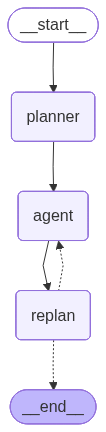

In [25]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [26]:
import uuid
import datetime
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage, BaseMessage

def start_conversation():
    thread_id = uuid.uuid4()
    print(f'Thread ID: {thread_id}')
    return {"configurable": {"thread_id": thread_id}, 'recursion_limit': 150}

def run_query(query, config):
    print(config['configurable']['thread_id'])
    msg = []
    for s in app.stream({"messages": [("user", query)]}, subgraphs=True, config=config):
        print(s)
        print("----")
        msg.append(s[-1])

    return msg

# def final_chat_response(response):
#     for resp in response:
#         for key, value in resp.items():
#             if key=="researcher":
#                 # print(value['messages'[-1]])
#                 display(Markdown(value['messages'][-1].content))
#     #return value['messages'][-1].content


def respond_question(app, question, config=start_conversation(), silent=True):
    print(f'config: {config}')
    inputs = {"input": question}
    msgs = []
    print('###QUESTION###')
    print(question)
    for event in app.stream(inputs, config=config):
        for k, v in event.items():
            if not silent:
                prettyprint(str(v))
            msgs.append(event)
    print('###RESPONSE###')
    prettyprint(msgs[-1]['replan']['response'])
    msgs[::-1]
    msgs2 = msgs[::-1]
    msgs2.append(question)
    msgs2 = msgs2[::-1]
    return msgs2, config

def follow_up(app, question, config, silent=True):
    response = respond_question(app, question, config, silent=silent)
    get_answer(response)
    return response

class FinalResponse(BaseModel):
    """Respond to the user with this"""
    final_response: str = Field(description="final response")

def repeat_test(question, n_runs=3):
    decision_prompt = ChatPromptTemplate([
        ("system", "You will be given the original question and a list with answers. Respond with the response that is most likely to be true based on the number of times it appears in the list."),
        ("human",
        """
        Given the original question:
        {question}
        and the answers given by the model:
        Return the answer chosen by the majority.
    """),
    MessagesPlaceholder(variable_name="messages", optional=True)
    ])

    llm_respond = decision_prompt | llm.with_structured_output(FinalResponse)
    run_memory = {}
    all_answers = []
    for r in range(n_runs):
        print(f"### RUN {r} ###")
        config = start_conversation(question)
        response = answer_question(question, config)
        run_memory.update({r: response})
        all_answers.append(get_answer(response))
    print("### FINAL ANSWER ###")
    msgs = []
    for msg in all_answers:
        msgs.append(HumanMessage(content=msg))
    response = llm_respond.invoke(msgs)
    print(response)
    return run_memory, all_answers

def get_answer(response):
    question = response[0]
    print('### QUESTION ###')
    print('### ANSWER ###')
    try:
        answer = response[-1]['replan']['response']
        print(answer)
    except Exception as e:
        print(e)

Thread ID: ec6f68be-1801-40fd-8d85-6bc0ba8d3cae


In [27]:
question =  "Give me the range of dates covered by the tables"
response, config = respond_question(app, question, silent=False)
get_answer(response)

config: {'configurable': {'thread_id': UUID('ec6f68be-1801-40fd-8d85-6bc0ba8d3cae')}, 'recursion_limit': 150}
###QUESTION###
Give me the range of dates covered by the tables
---Plan Step---
{'plan': ['Identify the earliest date in the database', 'Identify the latest
date in the database', 'Report the range of dates as the earliest date to the
latest date']}



---Execute Step---
### Call Simple Agent ###
query: For the following plan: 1. Identify the earliest date in the database 2.
Identify the latest date in the database 3. Report the range of dates as the
earliest date to the latest date  You are tasked with executing step 1, Identify
the earliest date in the database.



response: content="<think>\nOkay, let's tackle this problem. The user wants to
find the earliest date in the database. First, I need to figure out which tables
and columns contain date information. Since I don't know the database structure
yet, I should start by listing all the tables using sql_db_list_tables. Once

KeyError: 'response'